# Chapter 3 — Score-Based Generative Models / Score SDE (2-D)

**Theory reference**: `quickguide.tex` Chapter 3.

### What this notebook covers
1. Visualize the **true score field** $\nabla\log p(x)$ via KDE
2. Train an **NCSN** (discrete multi-scale DSM) and run annealed Langevin dynamics
3. Train a **VE-SDE** (continuous-time) and compare reverse SDE vs. probability flow ODE

### Key equations
**DSM loss** (Thm 3.3): $\mathcal{L}_{\text{DSM}}(\theta,\sigma_i) = \mathbb{E}_{x_0,\varepsilon}\bigl[\|s_\theta(\tilde x,\sigma_i)+\varepsilon/\sigma_i\|^2\bigr]$

**NCSN loss**: $\mathcal{L}_{\text{NCSN}} = \sum_i \sigma_i^2 \cdot \mathcal{L}_{\text{DSM}}(\theta,\sigma_i)$

**Annealed Langevin** (Def 3.4): $x_{k+1} = x_k + \tfrac{\alpha_i}{2}s_\theta(x_k,\sigma_i) + \sqrt{\alpha_i}z_k$

**Probability flow ODE** (§3.5): $\mathrm{d}x = -\tfrac{1}{2}g^2(t)\,s_\theta(x,t)\,\mathrm{d}t$

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cpu


In [6]:
from diffusion_lab.data import make_dataset, get_dataloader

DATASET = 'checkerboard'
x0_np   = make_dataset(DATASET, n=5000, seed=0)
x0      = torch.from_numpy(x0_np).to(DEVICE)
loader  = get_dataloader(DATASET, n=20_000, batch_size=512, seed=0, device=DEVICE)

## 1  True score field $\nabla\log p(x)$ via KDE

The score $\nabla_x\log p(x)$ points toward regions of higher density.
We estimate it numerically by differentiating a KDE.

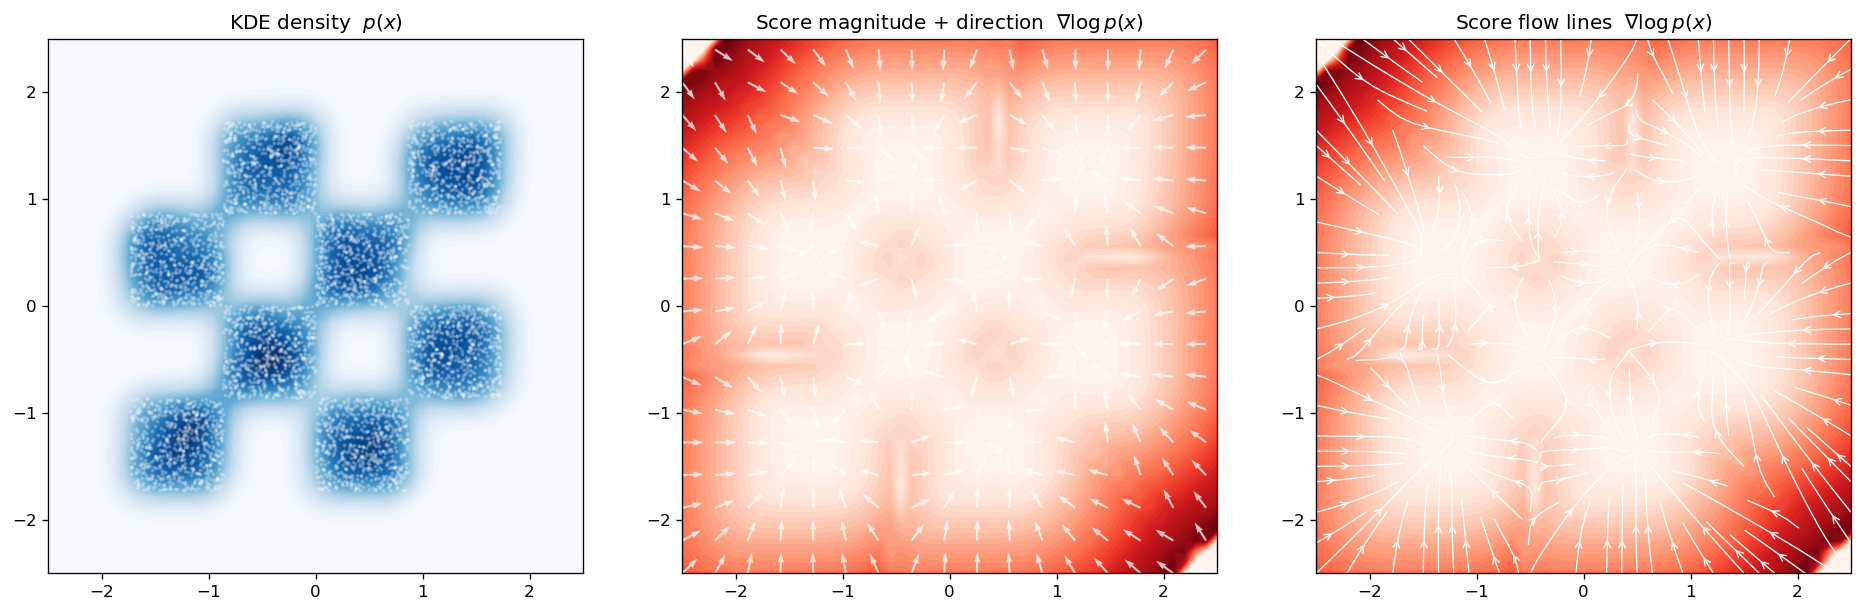

In [8]:
# Fit KDE on data
kde = gaussian_kde(x0_np.T, bw_method=0.15)

# Build 2-D grid (higher res for smoother stream lines)
res = 50
xs  = np.linspace(-2.5, 2.5, res)
ys  = np.linspace(-2.5, 2.5, res)
gx, gy = np.meshgrid(xs, ys)
grid   = np.stack([gx.ravel(), gy.ravel()], axis=0)   # (2, N)

# Numerical gradient of log-KDE
eps_fd = 1e-4
def score_kde(pts):
    dx = (np.log(kde(pts + np.array([[eps_fd],[0]])) + 1e-30)
         - np.log(kde(pts - np.array([[eps_fd],[0]])) + 1e-30)) / (2*eps_fd)
    dy = (np.log(kde(pts + np.array([[0],[eps_fd]])) + 1e-30)
         - np.log(kde(pts - np.array([[0],[eps_fd]])) + 1e-30)) / (2*eps_fd)
    return np.stack([dx, dy], axis=1)

scores = score_kde(grid)          # (N, 2)
U = scores[:, 0].reshape(res, res)   # x-component  (row=y, col=x)
V = scores[:, 1].reshape(res, res)   # y-component
mag = np.sqrt(U**2 + V**2)

# Normalise to unit vectors for streamplot (direction only, no length distortion)
U_norm = U / (mag + 1e-8)
V_norm = V / (mag + 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Panel 1: Density ─────────────────────────────────────────────────────
axes[0].contourf(gx, gy, kde(grid).reshape(res, res), levels=40, cmap='Blues')
axes[0].scatter(x0_np[:, 0], x0_np[:, 1], s=2, alpha=0.2, c='white')
axes[0].set_title('KDE density  $p(x)$')

# ── Panel 2: Score magnitude + raw quiver (sparse, normalised length) ────
axes[1].contourf(gx, gy, mag, levels=40, cmap='Reds')
sk = 3
axes[1].quiver(
    gx[::sk, ::sk], gy[::sk, ::sk],
    U_norm[::sk, ::sk], V_norm[::sk, ::sk],
    color='white', alpha=0.75,
    scale=25, width=0.004,        # fixed-length unit arrows
)
axes[1].set_title(r'Score magnitude + direction  $\nabla\log p(x)$')

# ── Panel 3: Streamplot — direction only, clean flow lines ───────────────
axes[2].contourf(gx, gy, mag, levels=40, cmap='Reds')
axes[2].streamplot(
    xs, ys, U_norm, V_norm,
    color='white', linewidth=0.8, density=1.2,
    arrowsize=1.0, arrowstyle='->'
)
axes[2].set_title(r'Score flow lines  $\nabla\log p(x)$')

for ax in axes:
    ax.set_aspect('equal')
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)

plt.tight_layout()
plt.show()

## 2  NCSN — Noise Conditional Score Network

Geometric noise schedule $\sigma_1 > \sigma_2 > \cdots > \sigma_L$.

In [9]:
from diffusion_lab.nn        import TimeMLP
from diffusion_lab.models    import NCSN
from diffusion_lab.training  import Trainer

L         = 10
SIGMA_MIN = 0.01
SIGMA_MAX = 2.0
sigmas    = torch.exp(torch.linspace(np.log(SIGMA_MAX), np.log(SIGMA_MIN), L))

print('Noise levels (σ_1 to σ_L):')
print([f'{s:.4f}' for s in sigmas.tolist()])

network = TimeMLP(in_dim=2, out_dim=2, hidden=256, depth=5,
                  time_embed_dim=128, residual=False).to(DEVICE)
ncsn    = NCSN(network, sigmas=sigmas).to(DEVICE)

trainer = Trainer(ncsn, loader, lr=3e-4, device=DEVICE, grad_clip=1.0)
losses  = trainer.train(n_steps=8_000, log_every=1000)
print(f'Initial: {losses[0]:.4f}  Final: {losses[-1]:.4f}')

Noise levels (σ_1 to σ_L):
['2.0000', '1.1101', '0.6162', '0.3420', '0.1898', '0.1054', '0.0585', '0.0325', '0.0180', '0.0100']


Training:   0%|          | 0/8000 [00:00<?, ?it/s]

Initial: 0.9559  Final: 0.8097


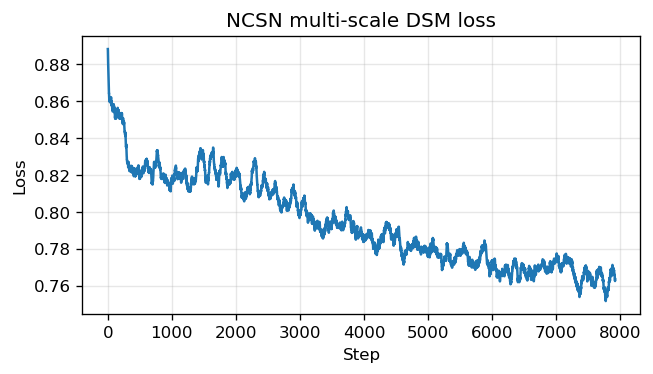

In [10]:
from diffusion_lab.utils import plot_loss_curve
plot_loss_curve(losses, smooth=80, title='NCSN multi-scale DSM loss')
plt.show()

### 2a  Learned score vs. true score at lowest noise level

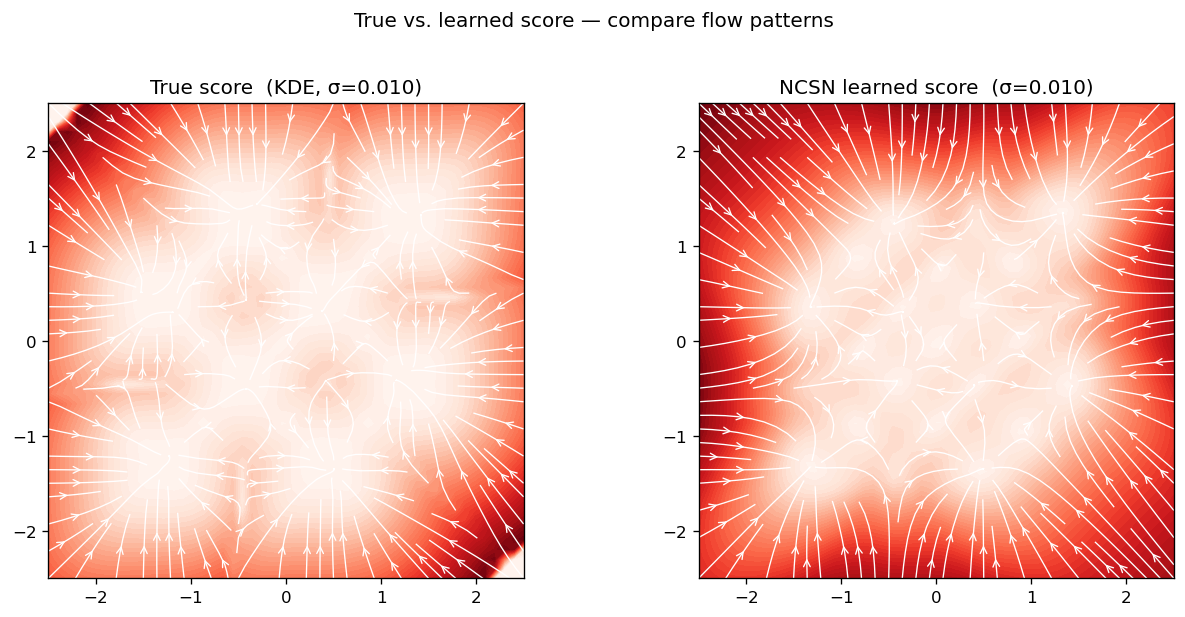

In [12]:
ncsn.eval()
sigma_L   = sigmas[-1]    # smallest σ
sigma_max = sigmas[0]

grid_t = torch.from_numpy(grid.T).float().to(DEVICE)   # (N, 2)
t_in   = torch.full((len(grid_t),), sigma_L / sigma_max, device=DEVICE)

with torch.no_grad():
    s_net = ncsn.network(grid_t, t_in).cpu().numpy()   # (N, 2)

s_kde = score_kde(grid)   # true score via KDE

def _norm(sv):
    """Normalise score vectors to unit length for clean streamplot."""
    mag = np.linalg.norm(sv, axis=1, keepdims=True)
    return sv / (mag + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, sv, title in [
    (axes[0], s_kde, f'True score  (KDE, σ={sigma_L:.3f})'),
    (axes[1], s_net, f'NCSN learned score  (σ={sigma_L:.3f})'),
]:
    mag    = np.linalg.norm(sv, axis=1).reshape(res, res)
    sv_n   = _norm(sv)
    U_n    = sv_n[:, 0].reshape(res, res)
    V_n    = sv_n[:, 1].reshape(res, res)

    ax.contourf(gx, gy, mag, levels=40, cmap='Reds')
    ax.streamplot(
        xs, ys, U_n, V_n,
        color='white', linewidth=0.8, density=1.2,
        arrowsize=1.0, arrowstyle='->',
    )
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)

plt.suptitle('True vs. learned score — compare flow patterns', y=1.02)
plt.tight_layout()
plt.show()

### 2b  Annealed Langevin dynamics sampling

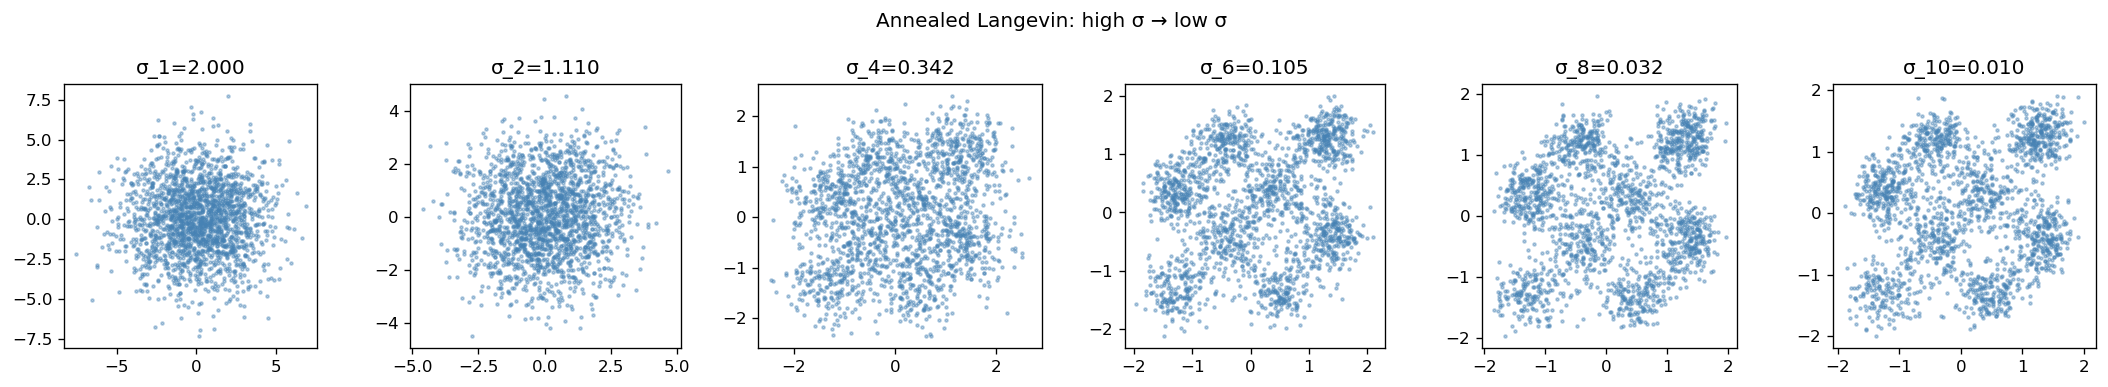

In [13]:
# Snapshot after each noise level
chain = ncsn.annealed_langevin(
    shape=(2000, 2), device=DEVICE,
    n_steps_per_level=200, step_lr=2e-5,
    return_chain=True, chain_levels=list(range(L)),
)

n_show = min(len(chain), 6)
idxs   = np.linspace(0, len(chain)-1, n_show, dtype=int)

fig, axes = plt.subplots(1, n_show, figsize=(3*n_show, 3))
from diffusion_lab.utils import plot_samples
for ax, i in zip(axes, idxs):
    plot_samples(chain[i].numpy(), ax=ax,
                 title=f'σ_{i+1}={sigmas[i]:.3f}', s=3, alpha=0.4)
plt.suptitle('Annealed Langevin: high σ → low σ', y=1.02)
plt.tight_layout()
plt.show()

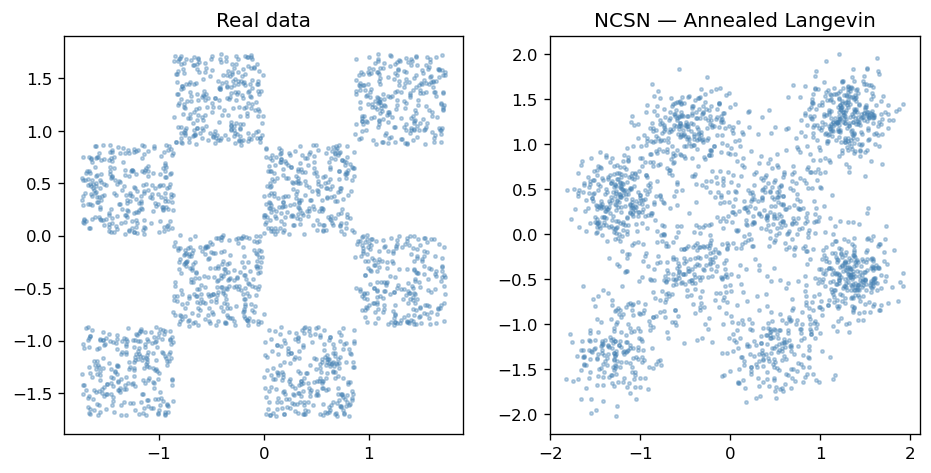

In [14]:
from diffusion_lab.utils import compare_panels

x_ncsn = ncsn.annealed_langevin((2000,2), device=DEVICE,
                                 n_steps_per_level=300, step_lr=2e-5)
compare_panels(x0_np[:2000], x_ncsn.cpu().numpy(),
               titles=['Real data', 'NCSN — Annealed Langevin'])
plt.show()

## 3  VE-SDE — Continuous-time score model

In [21]:
from diffusion_lab.models import VE_SDE

net_ve = TimeMLP(in_dim=2, out_dim=2, hidden=256, depth=5,
                 time_embed_dim=128, residual=False).to(DEVICE)
ve_sde = VE_SDE(net_ve, sigma_min=0.01, sigma_max=5.0).to(DEVICE)

tr_ve  = Trainer(ve_sde, loader, lr=3e-4, device=DEVICE, grad_clip=1.0)
losses_ve = tr_ve.train(n_steps=20_000, log_every=1000)
print(f'Initial: {losses_ve[0]:.4f}  Final: {losses_ve[-1]:.4f}')

Training:   0%|          | 0/20000 [00:00<?, ?it/s]

Initial: 1.0334  Final: 0.5855


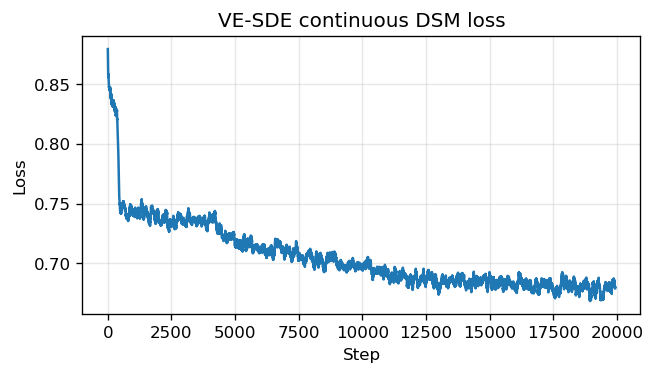

In [22]:
plot_loss_curve(losses_ve, smooth=80, title='VE-SDE continuous DSM loss')
plt.show()

### 3a  Reverse SDE vs. Probability Flow ODE

In [23]:
# Reverse SDE (stochastic)
chain_sde = ve_sde.reverse_sde_sample(
    (2000, 2), device=DEVICE, n_steps=500,
    return_chain=True, chain_stride=50,
)

# Probability flow ODE (deterministic)
chain_ode = ve_sde.ode_sample(
    (2000, 2), device=DEVICE, n_steps=200,
    return_chain=True, chain_stride=20,
)

print(f'SDE chain frames: {len(chain_sde)}')
print(f'ODE chain frames: {len(chain_ode)}')

SDE chain frames: 11
ODE chain frames: 11


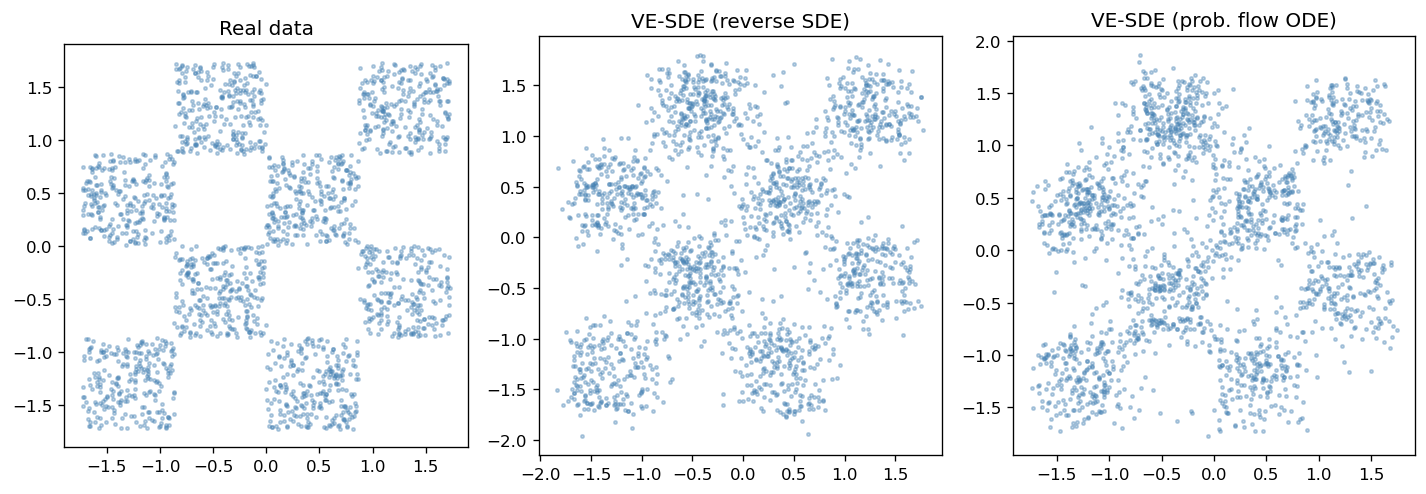

In [24]:
compare_panels(
    x0_np[:2000],
    chain_sde[-1].numpy(),
    chain_ode[-1].numpy(),
    titles=['Real data', 'VE-SDE (reverse SDE)', 'VE-SDE (prob. flow ODE)'],
)
plt.show()

### 3b  VE-SDE reverse chain animation (SDE)

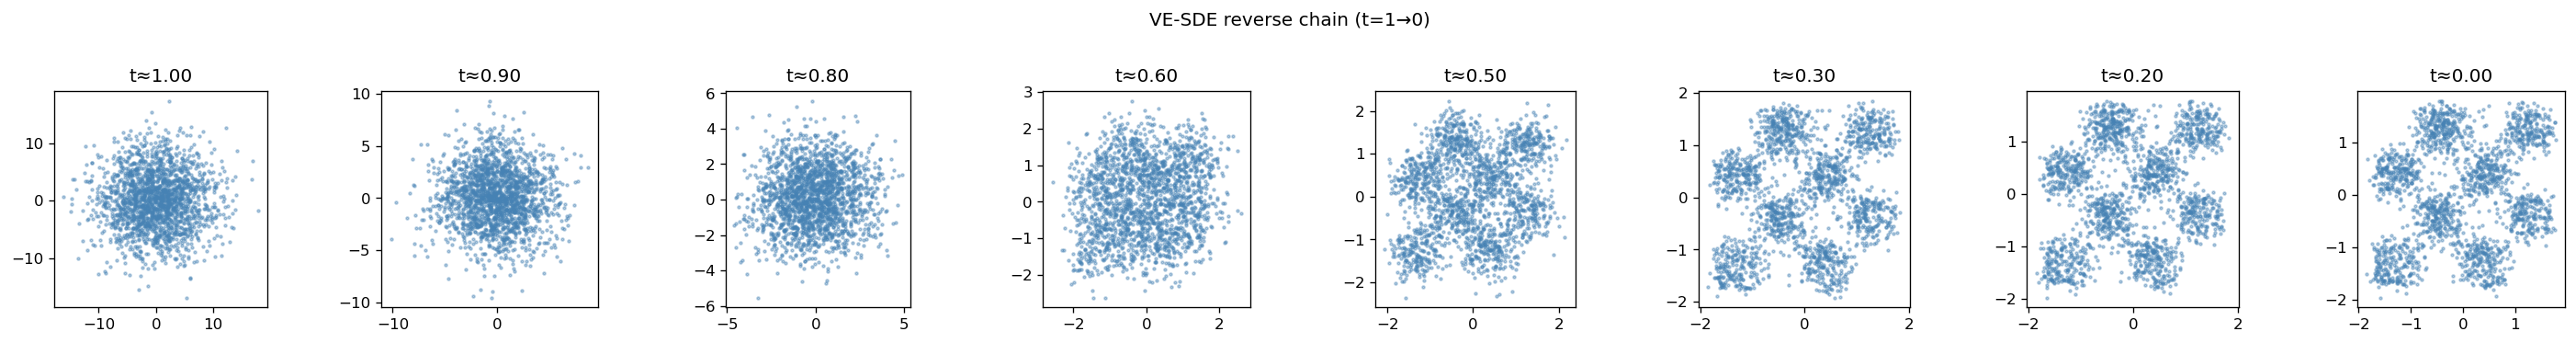

In [25]:
n_show = min(8, len(chain_sde))
idxs   = np.linspace(0, len(chain_sde)-1, n_show, dtype=int)
fig, axes = plt.subplots(1, n_show, figsize=(3*n_show, 3))
for ax, i in zip(axes, idxs):
    t_approx = 1.0 - i / (len(chain_sde)-1)
    plot_samples(chain_sde[i].numpy(), ax=ax,
                 title=f't≈{t_approx:.2f}', s=3, alpha=0.4)
plt.suptitle('VE-SDE reverse chain (t=1→0)', y=1.02)
plt.tight_layout()
plt.show()

## 4  NCSN vs. VE-SDE — side-by-side comparison

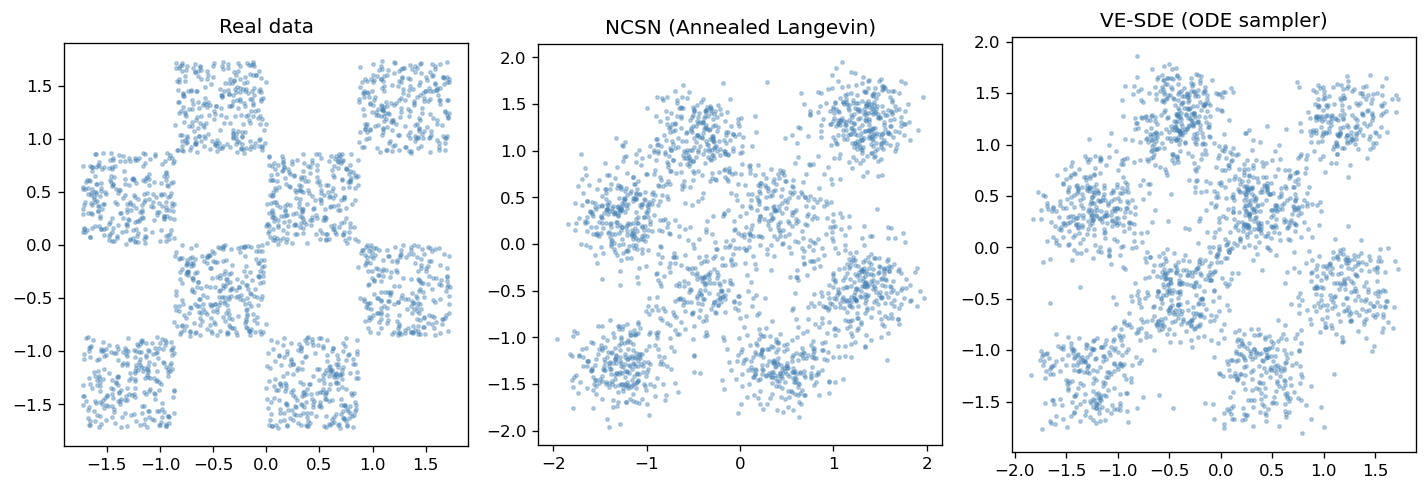

In [26]:
x_ncsn_final = ncsn.annealed_langevin((2000,2), device=DEVICE,
                                       n_steps_per_level=300, step_lr=2e-5)
x_ve_ode     = ve_sde.ode_sample((2000,2), device=DEVICE, n_steps=200)

compare_panels(
    x0_np[:2000],
    x_ncsn_final.cpu().numpy(),
    x_ve_ode.cpu().numpy(),
    titles=['Real data', 'NCSN (Annealed Langevin)', 'VE-SDE (ODE sampler)'],
)
plt.show()